In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
from scipy.interpolate import Rbf
from scipy.optimize import curve_fit

# ===== 中文显示设置 =====
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

多项式表达式:  
0.6 x + 1


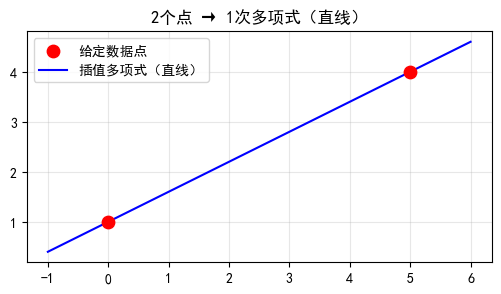

In [4]:
# 2个点 → 1次多项式（直线）
x_pts = np.array([0, 5])
y_pts = np.array([1, 4])

poly = lagrange(x_pts, y_pts)
print(f'多项式表达式: {poly}')

x_smooth = np.linspace(-1, 6, 100)
plt.figure(figsize=(6, 3))
plt.scatter(x_pts, y_pts, color='red', s=80, zorder=5, label='给定数据点')
plt.plot(x_smooth, poly(x_smooth), 'b-', label='插值多项式（直线）')
plt.grid(alpha=0.3)
plt.legend()
plt.title('2个点 → 1次多项式（直线）')
plt.show()

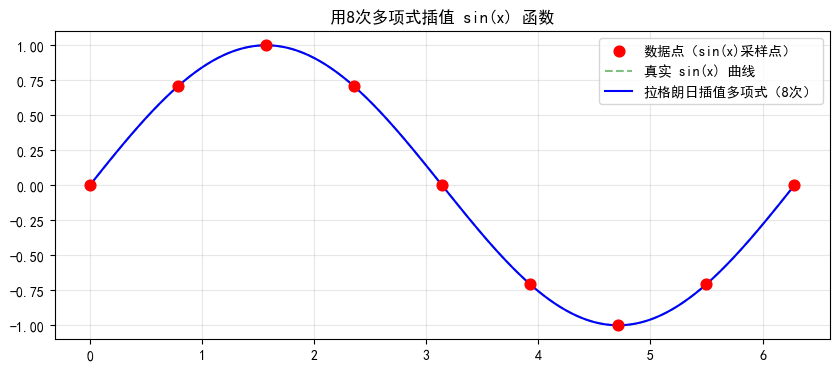

多项式系数（从高到低）:
[ 1.90960722e-18  1.52983021e-04 -3.36427235e-03  2.36203580e-02
 -3.89873432e-02 -1.10386434e-01 -4.21594490e-02  1.01239034e+00
  0.00000000e+00]


In [5]:
# 教材中的 sin(x) 插值：9个点，8次多项式
n_points = 9
x_pts = np.linspace(0, 2*np.pi, n_points)       # 每隔 pi/4 取点
y_pts = np.sin(x_pts)

poly = lagrange(x_pts, y_pts)

x_smooth = np.linspace(0, 2*np.pi, 500)
y_true = np.sin(x_smooth)
y_interp = poly(x_smooth)

plt.figure(figsize=(10, 4))
plt.scatter(x_pts, y_pts, color='red', s=60, zorder=5, label='数据点（sin(x)采样点）')
plt.plot(x_smooth, y_true, 'g--', alpha=0.5, label='真实 sin(x) 曲线')
plt.plot(x_smooth, y_interp, 'b-', label='拉格朗日插值多项式（8次）')
plt.grid(alpha=0.3)
plt.legend()
plt.title('用8次多项式插值 sin(x) 函数')
plt.show()

print(f'多项式系数（从高到低）:\n{poly.coef}')

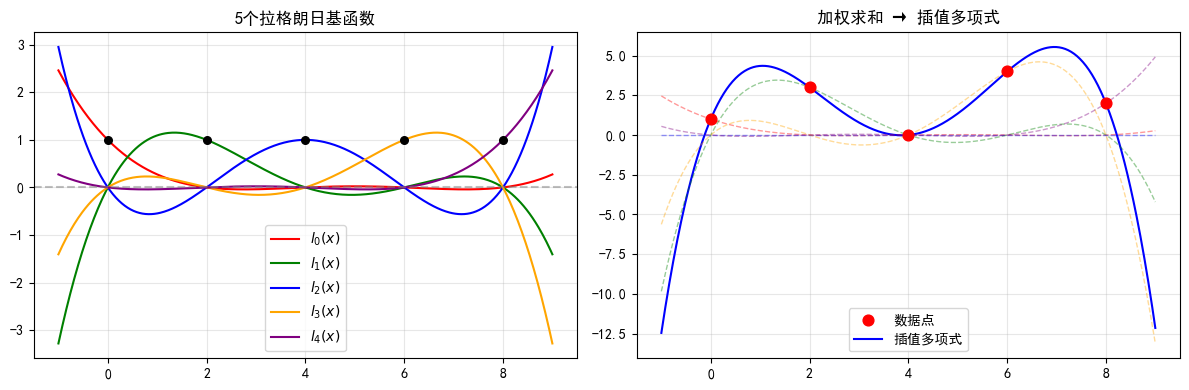

关键点：每个基函数 l_i(x) 在自己的节点处 = 1，在其他节点处 = 0
在 x=2 处，l_1(2)=1.00，其他基函数为0


In [6]:
def lagrange_basis(x_nodes, i, x):
    """计算第 i 个拉格朗日基函数在 x 处的值"""
    n = len(x_nodes)
    result = 1.0
    for j in range(n):
        if j != i:
            result *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
    return result

# 用 5 个点为例
x_nodes = np.array([0, 2, 4, 6, 8])
y_nodes = np.array([1, 3, 0, 4, 2])

x_smooth = np.linspace(-1, 9, 500)
plt.figure(figsize=(12, 4))

# 左图：5个基函数
plt.subplot(1, 2, 1)
colors = ['r', 'g', 'b', 'orange', 'purple']
for i in range(5):
    li = lagrange_basis(x_nodes, i, x_smooth)
    plt.plot(x_smooth, li, color=colors[i], label=f'$l_{i}(x)$', linewidth=1.5)
plt.scatter(x_nodes, np.ones(5), color='k', s=30, zorder=5)
plt.grid(alpha=0.3)
plt.legend()
plt.title('5个拉格朗日基函数')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 右图：加权求和得到插值多项式
plt.subplot(1, 2, 2)
poly = lagrange(x_nodes, y_nodes)
plt.scatter(x_nodes, y_nodes, color='red', s=60, zorder=5, label='数据点')
plt.plot(x_smooth, poly(x_smooth), 'b-', label='插值多项式')

for i in range(5):
    li = lagrange_basis(x_nodes, i, x_smooth)
    plt.plot(x_smooth, y_nodes[i] * li, '--', color=colors[i], alpha=0.4, linewidth=1)

plt.grid(alpha=0.3)
plt.legend()
plt.title('加权求和 → 插值多项式')

plt.tight_layout()
plt.show()

print('关键点：每个基函数 l_i(x) 在自己的节点处 = 1，在其他节点处 = 0')
print(f'在 x=2 处，l_1(2)={lagrange_basis(x_nodes, 1, 2):.2f}，其他基函数为0')

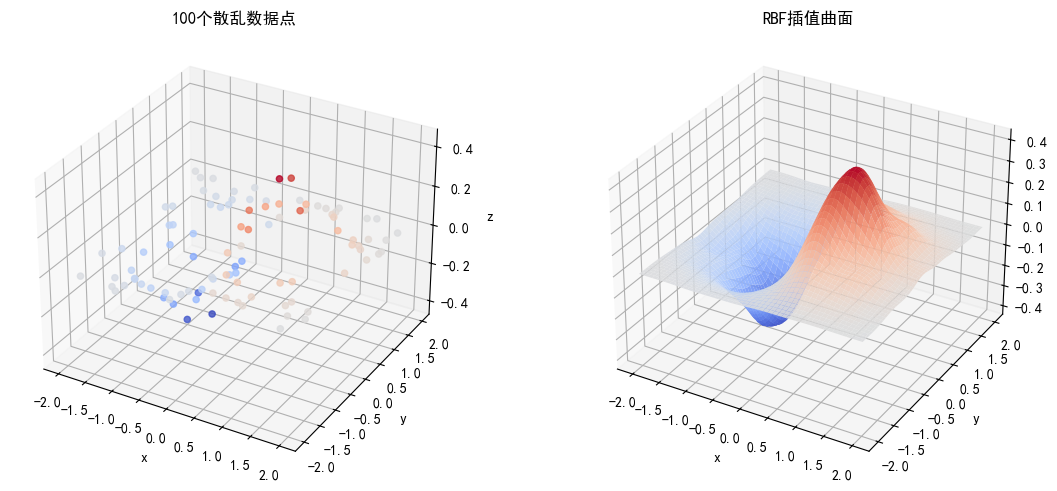

In [11]:
# 随机生成100个散乱数据点
np.random.seed(2026)
N = 100

x = np.random.rand(N) * 4 - 2   # [-2, 2]
y = np.random.rand(N) * 4 - 2   # [-2, 2]

# 二元函数 f(x,y) = x * exp(-x^2 - y^2)
z = x * np.exp(-x**2 - y**2)

# 用RBF插值
rbf = Rbf(x, y, z, function='gaussian')   # 高斯径向基函数

# 在密集网格上预测
xi = np.linspace(-2, 2, 100)
yi = np.linspace(-2, 2, 100)
XI, YI = np.meshgrid(xi, yi)
ZI = rbf(XI, YI)

# 画图
fig = plt.figure(figsize=(12, 5))

# 左图：散乱数据点
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(x, y, z, c=z, cmap='coolwarm', s=20, alpha=0.8)
ax1.set_title('100个散乱数据点')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

# 右图：RBF插值曲面
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(XI, YI, ZI, cmap='coolwarm', alpha=0.9)
ax2.set_title('RBF插值曲面')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

plt.tight_layout()
plt.show()

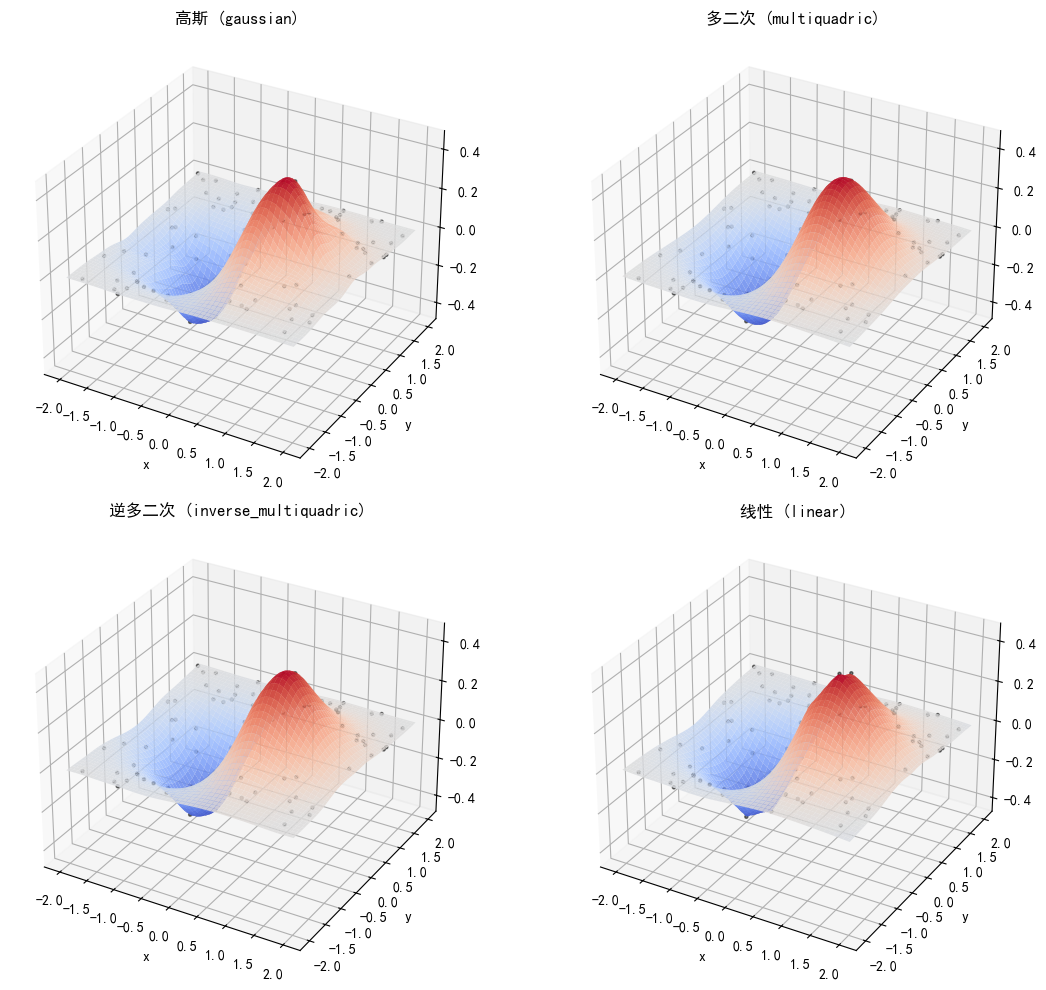

In [12]:
# 对比不同的径向基函数
functions = ['gaussian', 'multiquadric', 'inverse_multiquadric', 'linear']
titles = ['高斯', '多二次', '逆多二次', '线性']

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={'projection': '3d'})

for ax, func, title in zip(axes.flat, functions, titles):
    rbf = Rbf(x, y, z, function=func)
    ZI = rbf(XI, YI)
    ax.plot_surface(XI, YI, ZI, cmap='coolwarm', alpha=0.85)
    ax.scatter(x, y, z, c='k', s=5, alpha=0.5)
    ax.set_title(f'{title} ({func})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

真实参数:     a=2,    mu=0,   sigma=1
拟合结果:     a=1.981, mu=0.034, sigma=0.994
参数不确定度:  a=±0.040, mu=±0.023, sigma=±0.023


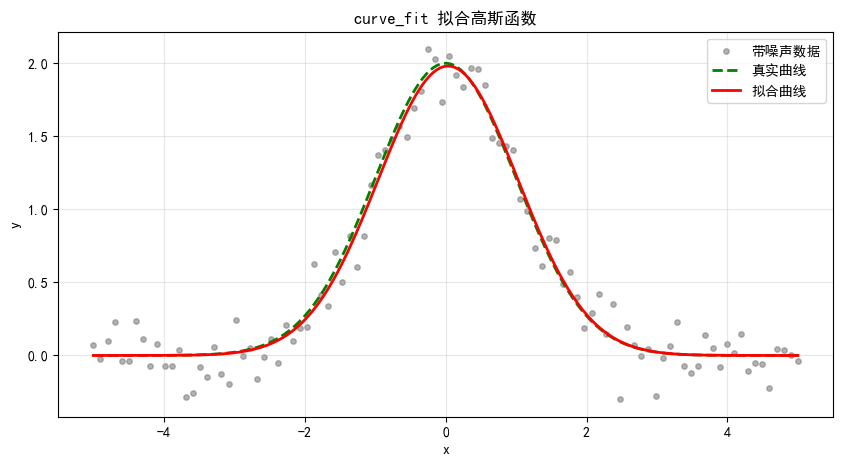

In [2]:
# 1. 定义高斯函数（待拟合模型）
def gaussian(x, a, mu, sigma):
    """a: 峰值, mu: 均值/中心位置, sigma: 标准差/宽度"""
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

# 2. 生成带噪声的模拟数据
np.random.seed(42)
x = np.linspace(-5, 5, 100)
# 真实参数: a=2, mu=0, sigma=1
y_true = gaussian(x, 2, 0, 1)
# 加上随机噪声
y_noisy = y_true + np.random.normal(0, 0.15, size=len(x))

# 3. 用 curve_fit 拟合
# p0 是初始猜测值（可选但有助于收敛）
p0 = [1, 0, 1]                     # [a, mu, sigma] 的初始猜测
popt, pcov = curve_fit(gaussian, x, y_noisy, p0=p0)

# popt: 最优参数 [a, mu, sigma]
# pcov: 参数的协方差矩阵
# （对角线开方 = 参数的标准差 = 拟合不确定度）

print(f"真实参数:     a=2,    mu=0,   sigma=1")
print(f"拟合结果:     a={popt[0]:.3f}, mu={popt[1]:.3f}, sigma={popt[2]:.3f}")
print(f"参数不确定度:  a=±{np.sqrt(pcov[0,0]):.3f}, "
      f"mu=±{np.sqrt(pcov[1,1]):.3f}, "
      f"sigma=±{np.sqrt(pcov[2,2]):.3f}")

# 4. 画图
x_smooth = np.linspace(-5, 5, 200)
y_fit = gaussian(x_smooth, *popt)

plt.figure(figsize=(10, 5))
plt.scatter(x, y_noisy, s=15, c='gray', alpha=0.6, label='带噪声数据')
plt.plot(x_smooth, gaussian(x_smooth, 2, 0, 1), 'g--', linewidth=2, label='真实曲线')
plt.plot(x_smooth, y_fit, 'r-', linewidth=2, label='拟合曲线')
plt.legend()
plt.grid(alpha=0.3)
plt.title('curve_fit 拟合高斯函数')
plt.xlabel('x')
plt.ylabel('y')
plt.show()